In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import h5py
import sys

In [2]:
trace_file = "trace.h5"

file = h5py.File(trace_file, "r")
print("文件中的所有键值:")
print(file.keys())
print("\n每个键值的详细信息:")
for key in file.keys():
    print(f"\n{key}:")
    if isinstance(file[key], h5py.Dataset):
        print(f"形状: {file[key].shape}")
    elif isinstance(file[key], h5py.Group):
        print("类型: Group")
        print("子键值:", list(file[key].keys()))

文件中的所有键值:
<KeysViewHDF5 ['Econ', 'Ecov', 'I_unpol', 'Kcon', 'Ladv', 'Mdot', 'MdotEdd', 'X', 'alpha_inv', 'b', 'b_k_angle', 'beta', 'dl', 'e2Constructed', 'e2ConstructedCov', 'e2Transported', 'e2TransportedCov', 'header', 'j_inv', 'j_unpol', 'k_unpol', 'ncoord', 'ne', 'nstep', 'ntetrad', 'nu', 'phi', 'prims', 'r', 'rho_inv', 'sigma', 'stokes', 'th', 'thetae']>

每个键值的详细信息:

Econ:
形状: (100, 100, 50000, 4, 4)

Ecov:
形状: (100, 100, 50000, 4, 4)

I_unpol:
形状: (100, 100, 50000)

Kcon:
形状: (100, 100, 50000, 4)

Ladv:
形状: ()

Mdot:
形状: ()

MdotEdd:
形状: ()

X:
形状: (100, 100, 50000, 4)

alpha_inv:
形状: (100, 100, 50000, 4)

b:
形状: (100, 100, 50000)

b_k_angle:
形状: (100, 100, 50000)

beta:
形状: (100, 100, 50000)

dl:
形状: (100, 100, 50000)

e2Constructed:
形状: (100, 100, 50000, 4)

e2ConstructedCov:
形状: (100, 100, 50000, 4)

e2Transported:
形状: (100, 100, 50000, 4)

e2TransportedCov:
形状: (100, 100, 50000, 4)

header:
类型: Group
子键值: ['Rin', 'Rout', 'camera', 'dsource', 'electrons', 'evpa_0', 'field_conf

# trace.h5文件中数组的含义

根据ipole源代码和trace.h5文件的内容，以下是各个数组的含义解释：

## 坐标和几何量
- **X**: 形状(100, 100, 50000, 4) - 四维时空坐标，包含(t, r, θ, φ)
- **r**: 形状(100, 100, 50000) - 径向坐标
- **th**: 形状(100, 100, 50000) - 极角坐标
- **phi**: 形状(100, 100, 50000) - 方位角坐标
- **dl**: 形状(100, 100, 50000) - 测地线上的步长

## 动力学量
- **Kcon**: 形状(100, 100, 50000, 4) - 光子的四波矢（逆变分量）
- **nstep**: 形状(100, 100) - 每条光线的步数

## 流体和等离子体参数
- **ne**: 形状(100, 100, 50000) - 电子数密度
- **thetae**: 形状(100, 100, 50000) - 无量纲电子温度 (kT_e/m_e c²)
- **b**: 形状(100, 100, 50000) - 磁场强度
- **beta**: 形状(100, 100, 50000) - 等离子体β参数 (气体压强/磁压强)
- **sigma**: 形状(100, 100, 50000) - 磁化参数 (磁能密度/静止质量能量密度)
- **b_k_angle**: 形状(100, 100, 50000) - 磁场与光子波矢之间的角度
- **prims**: 形状(100, 100, 50000, 8) - 原始变量数组，包含流体和磁场信息

## 辐射量
- **j_unpol**: 形状(100, 100, 50000) - 非偏振发射率
- **k_unpol**: 形状(100, 100, 50000) - 非偏振吸收系数
- **I_unpol**: 形状(100, 100, 50000) - 非偏振辐射强度
- **nu**: 形状(100, 100, 50000) - 光子频率
- **stokes**: 形状(100, 100, 50000, 4) - 斯托克斯参数 [I, Q, U, V]
- **j_inv**: 形状(100, 100, 50000, 4) - 偏振发射率的四矢量
- **rho_inv**: 形状(100, 100, 50000, 4) - 法拉第旋转和转换系数
- **alpha_inv**: 形状(100, 100, 50000, 4) - 偏振吸收系数的四矢量

## 四脚架和张量
- **Econ**: 形状(100, 100, 50000, 4, 4) - 四脚架的逆变分量
- **Ecov**: 形状(100, 100, 50000, 4, 4) - 四脚架的协变分量
- **ncoord**: 形状(100, 100, 50000, 4, 4) - 坐标系中的相干性张量
- **ntetrad**: 形状(100, 100, 50000, 4, 4) - 四脚架中的相干性张量

## 偏振传输相关
- **e2Constructed**: 形状(100, 100, 50000, 4) - 构造的偏振基矢（逆变分量）
- **e2ConstructedCov**: 形状(100, 100, 50000, 4) - 构造的偏振基矢（协变分量）
- **e2Transported**: 形状(100, 100, 50000, 4) - 平行传输的偏振基矢（逆变分量）
- **e2TransportedCov**: 形状(100, 100, 50000, 4) - 平行传输的偏振基矢（协变分量）

## 全局参数
- **Ladv**: 标量 - 吸积流的角动量通量
- **Mdot**: 标量 - 吸积率
- **MdotEdd**: 标量 - 爱丁顿吸积率

## header组中的参数
- **Rin**: 内边界半径
- **Rout**: 外边界半径
- **camera**: 相机参数
- **dsource**: 源距离
- **electrons**: 电子温度模型参数
- **evpa_0**: 电矢量位置角的参考方向
- **field_config**: 磁场配置
- **freqcgs**: 观测频率（CGS单位）
- **spin**: 黑洞自旋参数
- **t**: 模拟时间
- **units**: 单位系统参数
- **version**: ipole版本信息

## 数组形状说明
- 第一维和第二维(100, 100)：图像的像素数（nx × ny）
- 第三维(50000)：每条光线的最大步数
- 第四维(4)：四维时空的分量数
- 第五维(4)（在某些张量中）：四维时空的第二组分量数

这些数据允许您跟踪每条光线从相机到发射区域的完整路径，以及沿途的所有物理量，这对于理解黑洞周围的辐射过程和产生类似论文中图8的可视化非常有用。


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import h5py
from matplotlib.colors import LogNorm
import matplotlib.cm as cm

# 打开trace文件
trace_file = "/home/zzl/kx-4t/ipole/output/kharma/20250322_output/a09e00_trace_Rhigh1/torus.out0.00800_230GHz_trace.h5"
file = h5py.File(trace_file, "r")

img_i = 40
img_j = 45

# 获取数据
r = file['r'][img_i,img_j,:]  # 径向坐标
th = file['th'][img_i,img_j,:]  # 极角坐标
phi = file['phi'][img_i,img_j,:]  # 方位角坐标
nstep = file['nstep'][img_i,img_j]
j_unpol = file['j_unpol'][img_i,img_j,:]  # 非偏振发射率
dl = file['dl'][img_i,img_j,:]  # 测地线上的步长
stokes_I = file['stokes'][img_i,img_j,:,0]  # 斯托克斯参数 I

r_in = file['header']['Rin'][()]
r_out = file['header']['Rout'][()]
print(r_in, r_out)

nsteps = file['nstep'][img_i,img_j]
print(nsteps)

print(file['nstep'][:].max())


1.2238428620653632 50.0
1204
8983


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

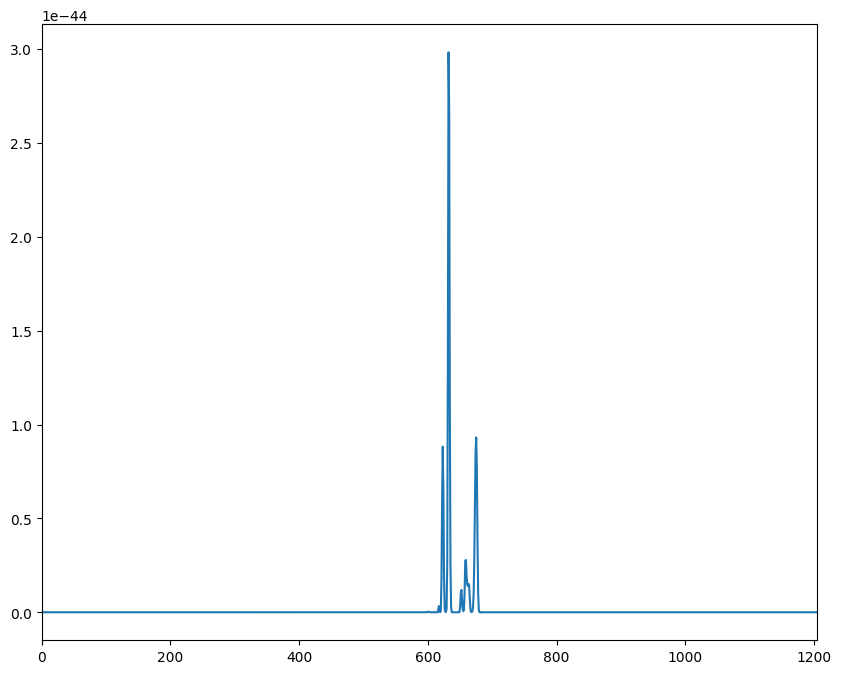

In [34]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(j_unpol)
ax.set_xlim(0, nsteps)
# ax.set_ylim(0, 3)
plt.show()

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

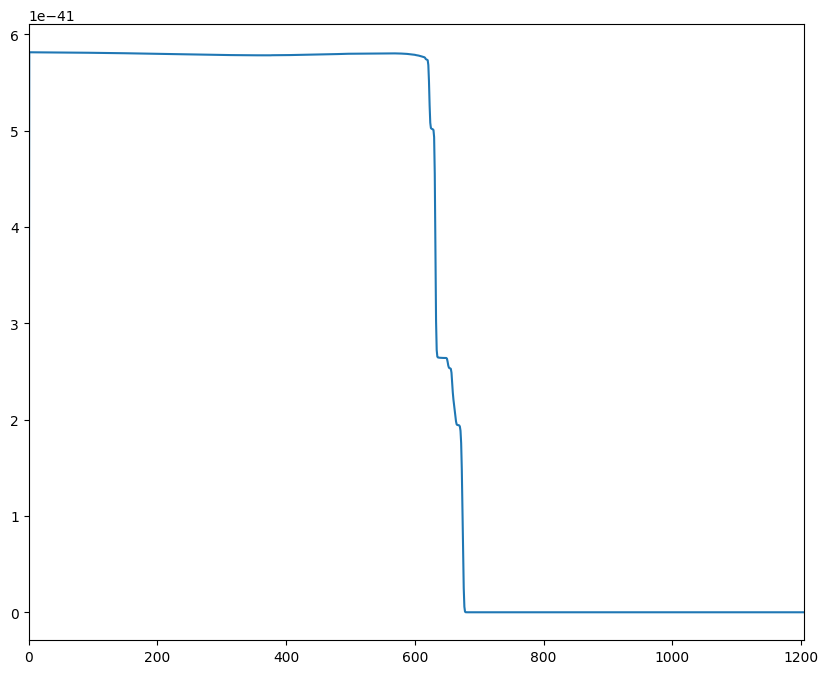

In [35]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(stokes_I)
ax.set_xlim(0, nsteps)
plt.show()

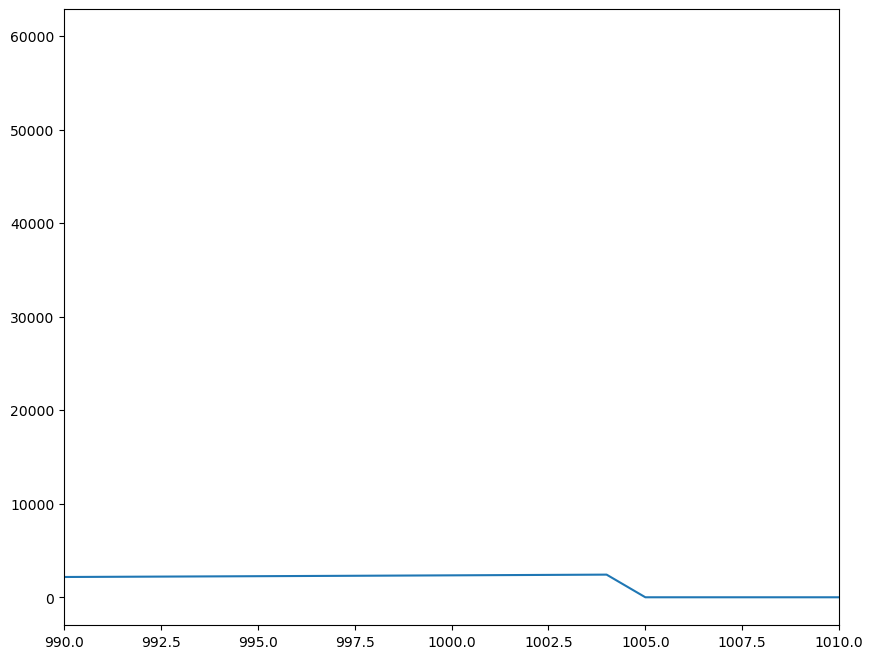

In [29]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(dl)
ax.set_xlim(990, 1010)
# ax.set_ylim(0, 1500)
plt.show()

In [39]:
r[1004]

99.59434617754641

In [36]:
dl[1004]

2422.3074249214465

创建一个离散的二维网格 (r, theta) ，只考虑 r小于20以内的范围，theta为0到pi。

nstep为每条测地线的索引最大值，不处理超过索引的部分。找到索引后，使用便确定了一条线上的每个点的坐标(r,theta,phi) 以及每个点对应的斯托克斯参数 I。在两个点之间对 I 做差值，就得到了两个点之间的辐射增量，对坐标值做平均就找到了辐射增量的产生的位置。phi不用考虑，这相当于在phi方向做了平均。在网格中找到辐射产生的位置，然后将I的增量加到此网格的位置。对所有测地线做此操作，则得到了亮度的来源。



In [7]:

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 10,        # 默认字体大小
    "axes.labelsize": 10,   # 轴标签字体大小
    "legend.fontsize": 10,  # 图例字体大小
    "axes.titlesize": 10,   # 标题字体大小
    "mathtext.fontset": "stix",  # 数学字体设置为 STIX，这个与 Times New Roman 很接近
})

8129


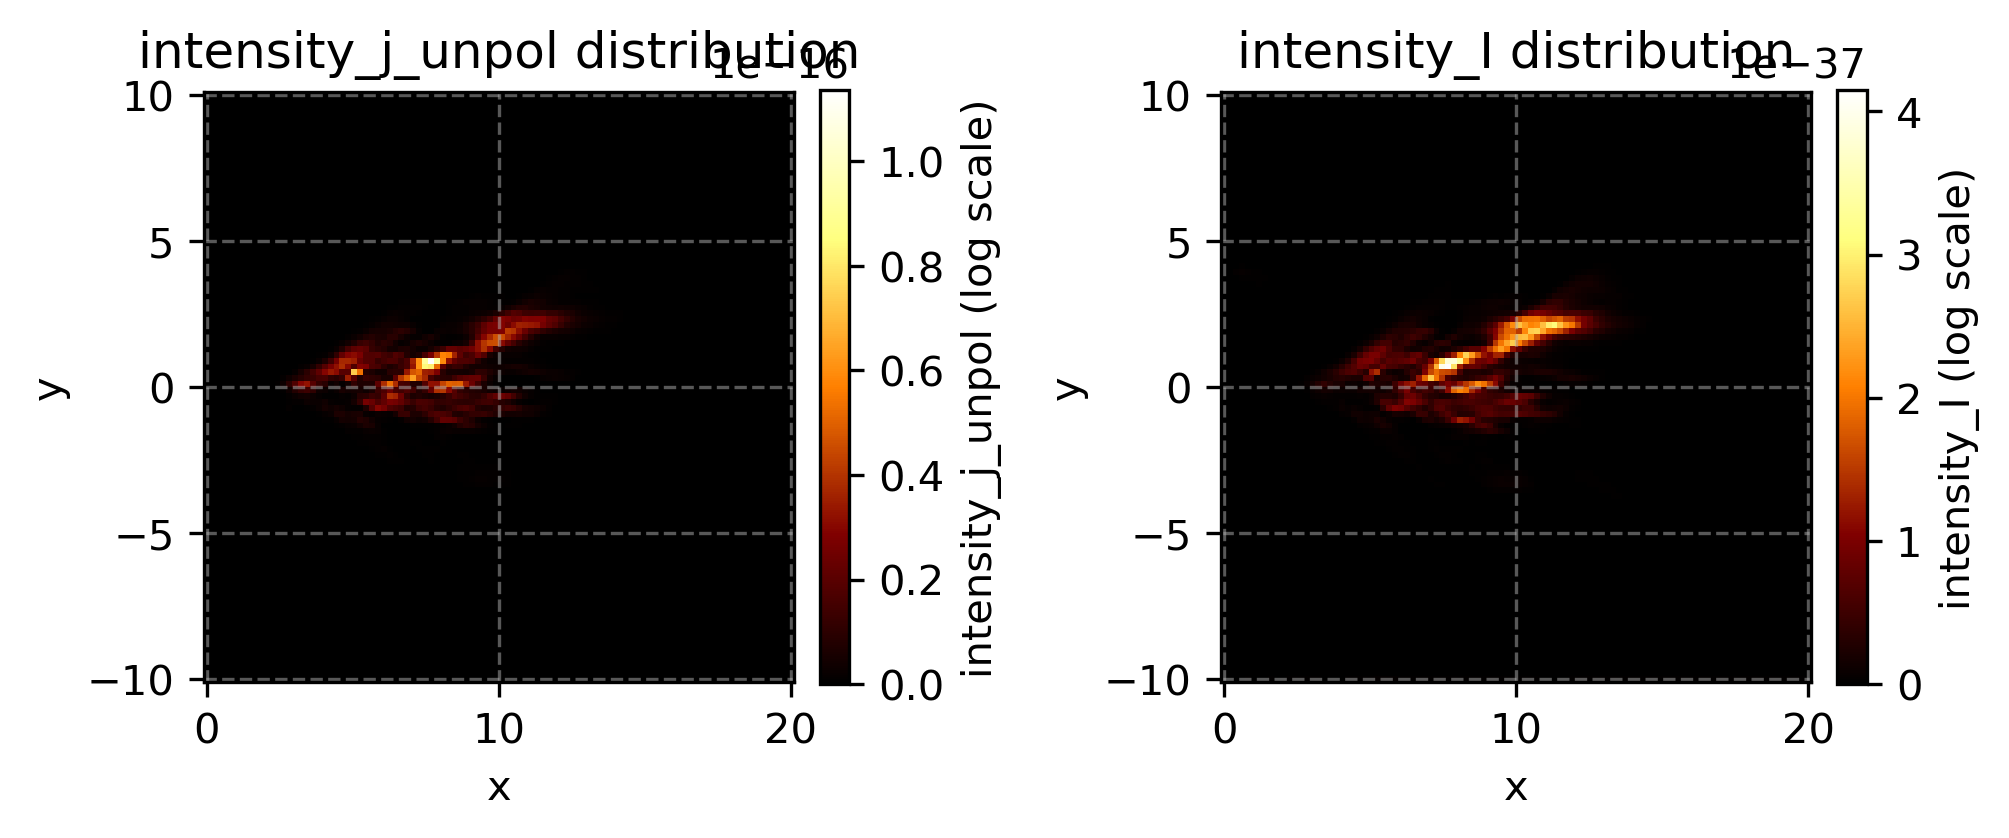

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from matplotlib.colors import LogNorm

resolution_x = 100
resolution_y = 100

range_x = 20
range_y = 20

# 创建笛卡尔坐标网格
x_grid = np.linspace(0, range_x, resolution_x)
y_grid = np.linspace(-range_y/2, range_y/2, resolution_y)
X, Y = np.meshgrid(x_grid, y_grid)


intensity_j_unpol = np.zeros_like(X)  # 用于存储辐射强度
intensity_I = np.zeros_like(X)  # 用于存储辐射强度

file_name = "/home/zzl/Projects/ipole/output/kharma_trace/20250406_output/a05e00_trace_Rhigh1/torus.out0.00600_230GHz_trace.h5"
# 打开数据文件
with h5py.File(file_name, 'r') as f:
    # 获取nstep数组以确定每条光线的长度
    nstep = f['nstep'][:]
    print(nstep.max())
    
    # 遍历每条测地线
    for i in range(nstep.shape[0]):
        for j in range(nstep.shape[1]):
            # 获取当前测地线的有效长度
            n = nstep[i,j]
            
            # print(len(f['r'][i,j]))
            # 只读取当前测地线的数据
            r_line = f['r'][i,j,:n]
            theta_line = f['th'][i,j,:n]
            j_line = f['j_inv'][i,j,:n,0] * (f['header']['freqcgs'][()]**2)
            I_line = f['stokes'][i,j,:n,0]
            # beta_line = f['beta'][i,j,:n]
            
            # 计算每个点之间的辐射增量并添加到网格中
            for k in range(len(r_line)-1):
                # 只处理r < 20的区域
                if r_line[k]*np.sin(theta_line[k]) > range_x or r_line[k+1]*np.sin(theta_line[k+1]) > range_x or r_line[k]*np.cos(theta_line[k]) > range_y/2 or r_line[k+1]*np.cos(theta_line[k+1]) > range_y/2:
                    continue
                    
                # 计算相邻点的笛卡尔坐标
                r_mid = (r_line[k] + r_line[k+1]) / 2
                theta_mid = (theta_line[k] + theta_line[k+1]) / 2
                x_mid = r_mid * np.sin(theta_mid)
                y_mid = r_mid * np.cos(theta_mid)
                
                # 计算辐射增量
                dI = -I_line[k+1] + I_line[k]
                
                # 找到最近的网格点
                x_idx = np.abs(x_grid - x_mid).argmin()
                y_idx = np.abs(y_grid - y_mid).argmin()
                
                # 将辐射增量加到对应的网格点
                intensity_j_unpol[y_idx, x_idx] += j_line[k]
                intensity_I[y_idx, x_idx] += dI

# 确保intensity不为负值
intensity_j_unpol = np.maximum(intensity_j_unpol, 1e-100)
intensity_I = np.maximum(intensity_I, 1e-100)

# 绘制结果
fig, axs = plt.subplots(1,2,figsize=(6.8, 4), dpi=300)

im0 = axs[0].pcolormesh(x_grid, y_grid, intensity_j_unpol, shading='auto', cmap='afmhot'
                        # ,norm=LogNorm(vmin=intensity_j_unpol.max()/1000, vmax=intensity_j_unpol.max())
                   )
plt.colorbar(im0, ax=axs[0], label='intensity_j_unpol (log scale)', fraction=0.046, pad=0.04)

im1 = axs[1].pcolormesh(x_grid, y_grid, intensity_I, shading='auto', cmap='afmhot'
                        # ,norm=LogNorm(vmin=intensity_I.max()/1000, vmax=intensity_I.max())
                        )
plt.colorbar(im1, ax=axs[1], label='intensity_I (log scale)', fraction=0.046, pad=0.04)

axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
axs[0].set_title('intensity_j_unpol distribution')

axs[1].set_xlabel('x')
axs[1].set_ylabel('y')
axs[1].set_title('intensity_I distribution')

# 添加网格线
axs[0].grid(True, linestyle='--', alpha=0.5)
axs[1].grid(True, linestyle='--', alpha=0.5)

# 优化显示
axs[0].set_aspect('equal')  # 使x和y轴比例相同
axs[1].set_aspect('equal')  # 使x和y轴比例相同
plt.tight_layout()

plt.show()



In [2]:
print(nstep.max())

8129


In [4]:
a = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
print(a[5:11:2])

[5, 7, 9]


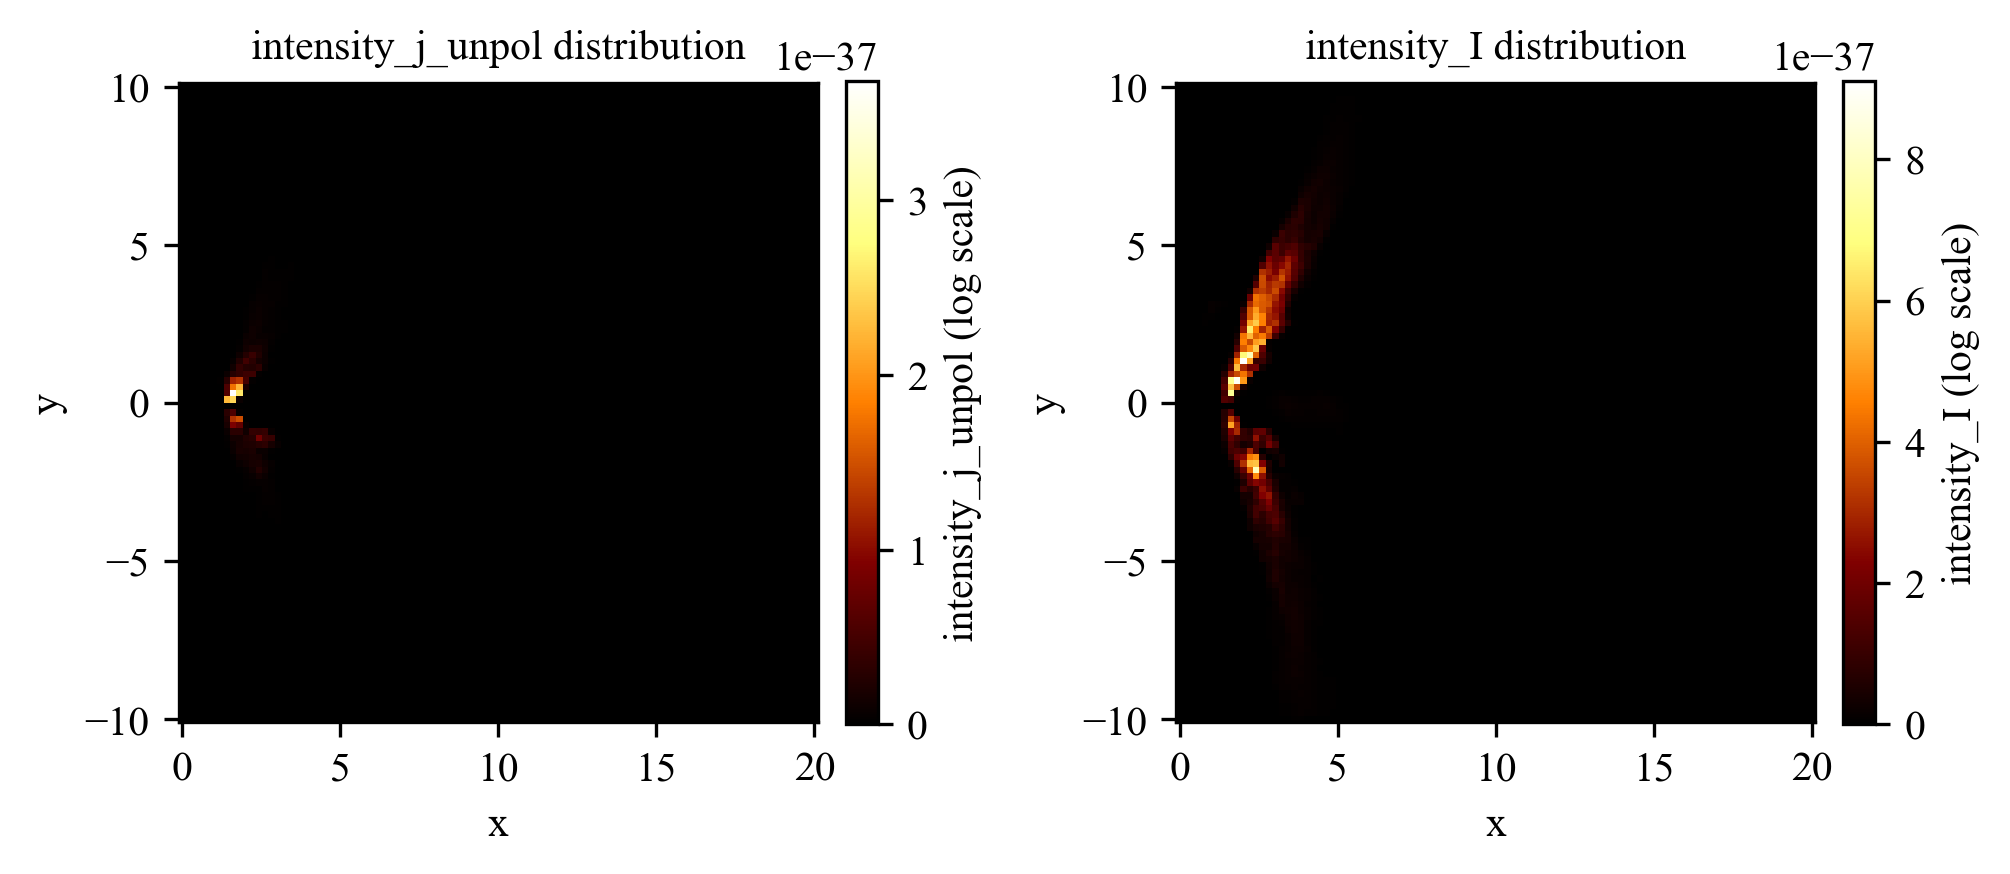

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from matplotlib.colors import LogNorm

resolution_x = 100
resolution_y = 100

range_x = 20
range_y = 20

# 创建笛卡尔坐标网格
x_grid = np.linspace(0, range_x, resolution_x)
y_grid = np.linspace(-range_y/2, range_y/2, resolution_y)
X, Y = np.meshgrid(x_grid, y_grid)


intensity_j_unpol = np.zeros_like(X)  # 用于存储辐射强度
intensity_I = np.zeros_like(X)  # 用于存储辐射强度

file_name = "/home/zzl/kx-4t/ipole/output/kharma/20250322_output/a09e00_trace_Rhigh160/torus.out0.00800_230GHz_trace.h5"
# 打开数据文件
with h5py.File(file_name, 'r') as f:
    # 获取nstep数组以确定每条光线的长度
    nstep = f['nstep'][:]
    
    # 遍历每条测地线
    for i in range(nstep.shape[0]):
        for j in range(nstep.shape[1]):
            # 获取当前测地线的有效长度
            n = nstep[i,j]
            
            # 只读取当前测地线的数据
            r_line = f['r'][i,j,:n]
            theta_line = f['th'][i,j,:n]
            j_unpol_line = f['j_inv'][i,j,:n,0]
            I_line = f['stokes'][i,j,:n,0]
            
            # 计算每个点之间的辐射增量并添加到网格中
            for k in range(len(r_line)-1):
                # 只处理r < 20的区域
                if not (r_line[k]*np.sin(theta_line[k]) < range_x and np.abs(r_line[k]*np.cos(theta_line[k])) < range_y/2):
                    continue
                    
                # 计算相邻点的笛卡尔坐标
                r_mid = (r_line[k] + r_line[k+1]) / 2
                theta_mid = (theta_line[k] + theta_line[k+1]) / 2
                x_mid = r_mid * np.sin(theta_mid)
                y_mid = r_mid * np.cos(theta_mid)
                
                # 计算辐射增量
                dI = -I_line[k+1] + I_line[k]
                
                # 找到最近的网格点
                x_idx = np.abs(x_grid - x_mid).argmin()
                y_idx = np.abs(y_grid - y_mid).argmin()
                
                # 将辐射增量加到对应的网格点
                intensity_j_unpol[y_idx, x_idx] += j_unpol_line[k]
                intensity_I[y_idx, x_idx] += dI

# 确保intensity不为负值
intensity_j_unpol = np.maximum(intensity_j_unpol, 1e-100)
intensity_I = np.maximum(intensity_I, 1e-100)

# 绘制结果
fig, axs = plt.subplots(1,2,figsize=(6.8, 4), dpi=300)

im0 = axs[0].pcolormesh(x_grid, y_grid, intensity_j_unpol, shading='auto', cmap='afmhot'
                        # ,norm=LogNorm(vmin=intensity_j_unpol.max()/1000, vmax=intensity_j_unpol.max())
                   )
plt.colorbar(im0, ax=axs[0], label='intensity_j_unpol (log scale)', fraction=0.046, pad=0.04)

im1 = axs[1].pcolormesh(x_grid, y_grid, intensity_I, shading='auto', cmap='afmhot'
                        # ,norm=LogNorm(vmin=intensity_I.max()/1000, vmax=intensity_I.max())
                   )
plt.colorbar(im1, ax=axs[1], label='intensity_I (log scale)', fraction=0.046, pad=0.04)

axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
axs[0].set_title('intensity_j_unpol distribution')

axs[1].set_xlabel('x')
axs[1].set_ylabel('y')
axs[1].set_title('intensity_I distribution')

# 添加网格线
# axs[0].grid(True, linestyle='--', alpha=0.5)
# axs[1].grid(True, linestyle='--', alpha=0.5)

# 优化显示
axs[0].set_aspect('equal')  # 使x和y轴比例相同
axs[1].set_aspect('equal')  # 使x和y轴比例相同
plt.tight_layout()

plt.show()



/tmp/ipykernel_558355/3624763233.py:59: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(X, Y, intensity, shading='auto', cmap='afmhot',


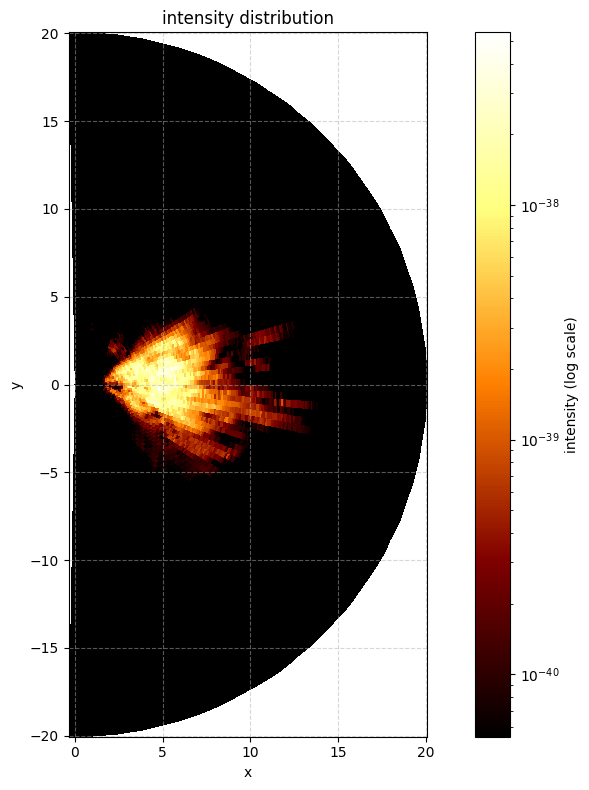

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from matplotlib.colors import LogNorm

# 创建二维网格
r_grid = np.linspace(0, 20, 200)  # r从0到20,分100个点
theta_grid = np.linspace(0, np.pi, 90)  # theta从0到pi,分50个点
R, THETA = np.meshgrid(r_grid, theta_grid)

# 转换为笛卡尔坐标
X = R * np.sin(THETA)  # x = r * sin(theta)
Y = R * np.cos(THETA)  # y = r * cos(theta)

intensity = np.zeros_like(R)  # 用于存储辐射强度

file_name = "/home/zzl/kx-4t/ipole/output/kharma/20250322_output/a09e00_trace_Rhigh1/torus.out0.00800_230GHz_trace.h5"
# 打开数据文件
with h5py.File(file_name, 'r') as f:
    # 获取nstep数组以确定每条光线的长度
    nstep = f['nstep'][:]
    
    # 遍历每条测地线
    for i in range(nstep.shape[0]):
        for j in range(nstep.shape[1]):
            # 获取当前测地线的有效长度
            n = nstep[i,j]
            
            # 只读取当前测地线的数据
            r_line = f['r'][i,j,:n]
            theta_line = f['th'][i,j,:n]
            I_line = -f['stokes'][i,j,:n,0]
            
            # 计算每个点之间的辐射增量并添加到网格中
            for k in range(len(r_line)-1):
                # 只处理r < 20的区域
                if r_line[k] > 20 or r_line[k+1] > 20:
                    continue
                    
                # 计算相邻点的平均r和theta
                r_mid = (r_line[k] + r_line[k+1]) / 2
                theta_mid = (theta_line[k] + theta_line[k+1]) / 2
                
                # 计算辐射增量
                dI = I_line[k+1] - I_line[k]
                
                # 找到最近的网格点
                r_idx = np.abs(r_grid - r_mid).argmin()
                theta_idx = np.abs(theta_grid - theta_mid).argmin()
                
                # 将辐射增量加到对应的网格点
                intensity[theta_idx, r_idx] += dI

# 确保intensity不为负值
intensity = np.maximum(intensity, 1e-100)

# 绘制结果
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.pcolormesh(X, Y, intensity, shading='auto', cmap='afmhot', 
                   norm=LogNorm(vmin=intensity.max()/1000, vmax=intensity.max()))
plt.colorbar(im, label='intensity (log scale)')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('intensity distribution')

# 添加网格线
ax.grid(True, linestyle='--', alpha=0.5)

# 优化显示
ax.set_aspect('equal')  # 使x和y轴比例相同
plt.tight_layout()

plt.show()

